# Preprocess the ScanNet++

In [3]:
# scene_id = "2a1a3afad9"
scene_id = "0a7cc12c0e"
# scene_id = "47eb87b5bb"

In preprocess env

1. download the file to `/data/scannetpp/data`

2. preprocess

  run (replace scene001, scene002, scene003 with your scene_ids)

```bash
  cd data/scannetpp

  python -m iphone.prepare_iphone_data iphone/configs/prepare_iphone_data.yml --scene_ids scene001 scene002 scene003
  
  python -m common.render common/configs/render.yml --scene_ids scene001 scene002 scene003

  cd ../..
```
3. use SAM to generate `output/mask` (run the following code)

In [1]:
import torch
from segment_anything import sam_model_registry, SamPredictor

print("CUDA available:", torch.cuda.is_available())

sam_checkpoint = "sam_vit_h_4b8939.pth"
model_type = "vit_h" 

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device="cuda")

print("SAM loaded successfully!")


CUDA available: True
SAM loaded successfully!


In [ ]:
from tqdm import tqdm
import os
import numpy as np
import cv2
import torch
from glob import glob
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

# === Step 1: Load SAM ===
sam_checkpoint = "sam_vit_h_4b8939.pth"
model_type = "vit_h"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint).to("cuda")

mask_generator = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=16,
    pred_iou_thresh=0.9,
    stability_score_thresh=0.96,
    min_mask_region_area=500
)

# === Step 2: Path ===
input_dir = "data/scannetpp/data/2a1a3afad9/iphone/render_rgb"
output_dir = "data/scannetpp/data/2a1a3afad9/output/mask"
os.makedirs(output_dir, exist_ok=True)

image_paths = sorted(glob(os.path.join(input_dir, "*.jpg")))

# === Step 3: Process ===
for image_path in tqdm(image_paths, desc="SAM Segmentation"):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    masks = mask_generator.generate(image)

    height, width = image.shape[:2]
    instance_mask = np.zeros((height, width), dtype=np.uint8)

    for idx, mask in enumerate(masks):
        instance_mask[mask["segmentation"]] = idx + 1 

    out_name = os.path.basename(image_path).replace(".jpg", ".png")
    cv2.imwrite(os.path.join(output_dir, out_name), instance_mask)



4. generate pth file by running following codes

In [ ]:
import open3d as o3d
import torch
from pathlib import Path

ply_path = "data/scannetpp/data/" + scene_id + "/scans/mesh_aligned_0.05.ply"

output_dir = Path("data/scannetpp/pcld_0.25")
output_dir.mkdir(parents=True, exist_ok=True)

output_pth = output_dir / f"{scene_id}.pth"

mesh = o3d.io.read_triangle_mesh(ply_path)

points = mesh.vertices
points_np = torch.tensor(points, dtype=torch.float32)

print(f"Loaded mesh with {len(points_np)} vertices.")

save_dict = {
    "sampled_coords": points_np
}

torch.save(save_dict, output_pth)
print(f"✅ Saved point cloud to: {output_pth}")


Loaded mesh with 1316969 vertices.
✅ Saved point cloud to: /home/vlm_caption/VLM_Caption/MaskClustering-main/data/scannetpp/pcld_0.25/2a1a3afad9.pth


# MaskClustering

In MaskClustering env

1. run
```bash
  python run.py --config scannetpp
```

2. the result is a npy file in `output/objcet`

also you can find a npz find for visualization in `data/prediction/scannetpp_class_agnostic`

3. visualization

run (replace scene_id with your scene_id)

```bash
  python -m visualize.vis_scene --config scannetpp --seq_name scene_id
```

4. download the file in 

`data/vis`

locally run 

```bash
python3 -m http.server 8000
```

and open https://localhost:8000 in a browser for visualization

# Result

In [6]:
import numpy as np

file_path = "data/scannetpp/data/" + scene_id + "/output/object/scannetpp/object_dict.npy"

id = 0

data = np.load(file_path, allow_pickle=True).item()[id]

repre_mask_list = data['repre_mask_list']
print(data['point_ids'][:5])
print(data['mask_list'][:10])
print(data['repre_mask_list'])
print("\nValue details:")
for key, value in data.items():
    print(f"{key}: type = {type(value)}")
    if hasattr(value, 'shape'):
        print(f"  shape = {value.shape}")
    elif isinstance(value, (list, dict)):
        print(f"  length = {len(value)}")
    else:
        print(f"  value = {value}")

[401408 401409 401410 401411 401412]
[(1070, 42, 0.8847865933490443), (400, 44, 0.8829536527886881), (360, 1, 0.8769311338046609), (340, 46, 0.859910971458497), (380, 26, 0.8507462686567164), (320, 1, 0.8431526577638125), (420, 37, 0.8311076197957581), (2120, 2, 0.8127782141921969), (1050, 1, 0.769835035349568), (2140, 2, 0.7350091647028018)]
[(1070, 42, 0.8847865933490443), (400, 44, 0.8829536527886881), (360, 1, 0.8769311338046609), (340, 46, 0.859910971458497), (380, 26, 0.8507462686567164)]

Value details:
point_ids: type = <class 'numpy.ndarray'>
  shape = (2986,)
mask_list: type = <class 'list'>
  length = 68
repre_mask_list: type = <class 'list'>
  length = 5


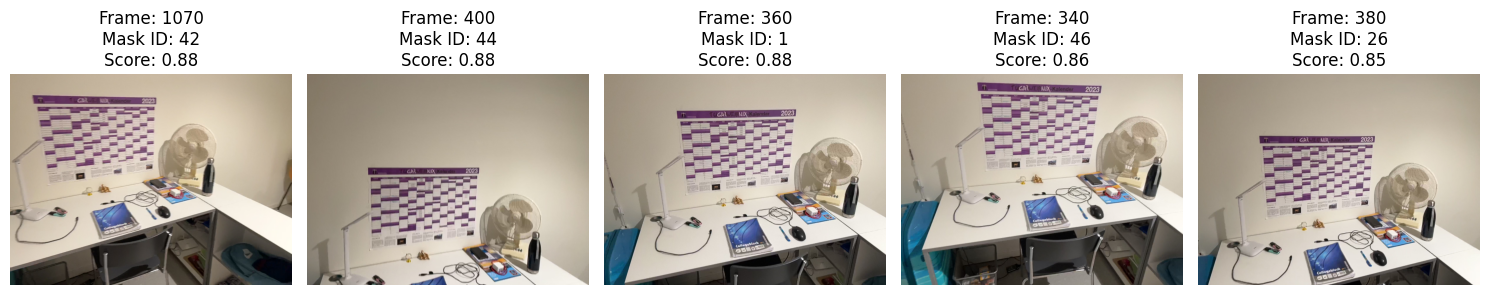

In [7]:
import cv2
import matplotlib.pyplot as plt
import os

image_dir = "data/scannetpp/data/" + scene_id + "/iphone/rgb"

plt.figure(figsize=(15, 8))

for i, (frame_id, mask_id, score) in enumerate(repre_mask_list):
    image_filename = f"frame_{frame_id:06d}.jpg"
    image_path = os.path.join(image_dir, image_filename)
    
    image = cv2.imread(image_path)
    if image is None:
        print(f"Warning: Image {image_path} not found!")
        continue
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    plt.subplot(1, len(repre_mask_list), i+1)
    plt.imshow(image_rgb)
    plt.title(f"Frame: {frame_id}\nMask ID: {mask_id}\nScore: {score:.2f}")
    plt.axis('off')

plt.tight_layout()
plt.show()
